In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

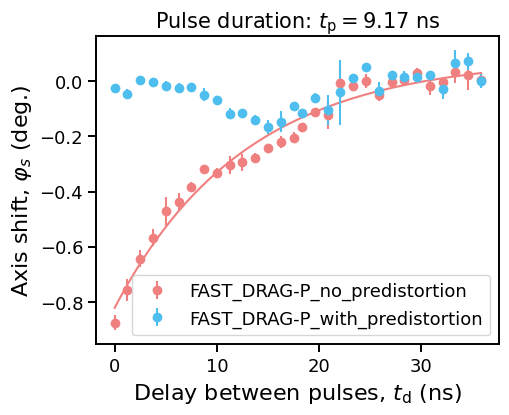

In [2]:
#Re-read csv-files and plot
pulse_names = ['FAST_DRAG-P_no_predistortion', 'FAST_DRAG-P_with_predistortion']

light_blue = [0.3010, 0.7450, 0.9330]
light_red = [240/255,128/255,128/255]

colors_dict = {'FAST_DRAG-P_with_predistortion': light_blue,
               'FAST_DRAG-P_no_predistortion': light_red,

    }

fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    axis_shift_vs_delay_exp_arr = np.genfromtxt(os.path.join(pulse, 'axis_shift_vs_delay_exp_arr.csv'), delimiter=',')
    axis_shift_uncertainty_vs_delay_exp_arr = np.genfromtxt(os.path.join(pulse, 'axis_shift_uncertainty_vs_delay_exp_arr.csv'), delimiter=',')
    delay_exp_arr = np.genfromtxt(os.path.join(pulse, 'delay_exp_arr.csv'), delimiter=',')
    pulse_duration = np.genfromtxt(os.path.join(pulse, 'pulse_duration.csv'), delimiter=',')

    plt.errorbar(delay_exp_arr*1e9, axis_shift_vs_delay_exp_arr, yerr=axis_shift_uncertainty_vs_delay_exp_arr, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))
    if pulse == 'FAST_DRAG-P_no_predistortion':
        axis_shift_vs_delay_fit_arr = np.genfromtxt(os.path.join(pulse, 'axis_shift_vs_delay_fit_arr.csv'), delimiter=',')
        delay_fit_arr = np.genfromtxt(os.path.join(pulse, 'delay_fit_arr.csv'), delimiter=',')
        plt.plot(delay_fit_arr*1e9, axis_shift_vs_delay_fit_arr, '-', color=colors_dict[pulse])

plt.xlabel('Delay between pulses, $t_\mathrm{d}$ (ns)', fontsize = 16)
#plt.ylabel(r'Gate error ($\times 10^{-4}$)', fontsize = 16)
plt.ylabel(r'Axis shift, $\varphi_s$ (deg.)', fontsize = 16)
plt.legend(fontsize = 13, loc = 'lower right', frameon = True) #'upper right')
plt.title('Pulse duration: $t_\mathrm{p} = %.2f$ ns'%(pulse_duration*1e9), fontsize=15)
ax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
